# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [1]:
# Import standard libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pubchempy as pcp
import tarfile
import re

from sklearn.preprocessing import StandardScaler
from statsmodels.api import add_constant, OLS, Logit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import statsmodels.api as sm
from sklearn.metrics import balanced_accuracy_score
from sklearn.neural_network import MLPClassifier

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs import ConvertToNumpyArray
import umap.umap_ as umap


/Users/Bella/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
# Load training data
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
print("Shape of the master file:", master_file.shape)
master_file.head()

Shape of the master file: (48152, 114)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_94867/3102753570.py:2: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.1080G>A,bacA_c.1080G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [59]:
# check distribution of WHO grades
print(master_file["gene"].value_counts().sort_index())
print(len(master_file["gene"].unique()))
print(master_file["gene"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

gene
PPE35       674
Rv0010c     511
Rv0565c     393
Rv0678      453
Rv1129c    1806
           ... 
tlyA        214
tsnR        129
ubiA        315
whiB6      1259
whiB7       506
Name: count, Length: 65, dtype: int64
65
gene
PPE35      0.013997
Rv0010c    0.010612
Rv0565c    0.008162
Rv0678     0.009408
Rv1129c    0.037506
             ...   
tlyA       0.004444
tsnR       0.002679
ubiA       0.006542
whiB6      0.026146
whiB7      0.010508
Name: proportion, Length: 65, dtype: float64


In [28]:
# Drop some initial columns that we won't be using, many which are text results and would be difficult to use for models
keep_columns = ['mutation', 'drug','gene','FINAL CONFIDENCE GRADING']
master_file_clean = master_file.copy()
master_file_clean = master_file_clean[keep_columns]

In [30]:
# check distribution of WHO grades
print(master_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(master_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


In [37]:
# Splitting the mutation column up to make fewer columns when one hot encoding
import re
# Amino acid 3-letter to 1-letter code map
AA_MAP = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Gln': 'Q', 'Glu': 'E', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V',
    'Ter': '*', 'Stop': '*'
}

def parse_aa(code):
    """Convert 3-letter amino acid code to 1-letter, or return as-is if already 1-letter or stop."""
    if code == '*':
        return '*'
    return AA_MAP.get(code, code)


def extract_features(mutation):

    PREFIX = r'[cn]\.'

    # -------------------------
    # PROTEIN-LEVEL: p. notation
    # -------------------------

    # Stop extension: p.Ter559Glnext*? or p.Ter559ext*? or p.Ter628Serext*?
    p_ext = re.match(r'p\.Ter(\d+)([A-Z][a-z]{2})?ext\*\?$', mutation)
    if p_ext:
        pos, alt_aa = p_ext.groups()
        return {'mut_type': 'extension', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': '*', 'alt': parse_aa(alt_aa) if alt_aa else None}

    # Stop codon unknown delins: p.Ter839delins???
    p_ter_delins = re.match(r'p\.Ter(\d+)delins\?+$', mutation)
    if p_ter_delins:
        pos = p_ter_delins.group(1)
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': '*', 'alt': None}

    # Frameshift: p.Asp379fs
    p_fs = re.match(r'p\.([A-Z][a-z]{2})(\d+)fs$', mutation)
    if p_fs:
        ref_aa, pos = p_fs.groups()
        return {'mut_type': 'frameshift', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Stop/nonsense: p.Trp122*
    p_stop = re.match(r'p\.([A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_stop:
        ref_aa, pos = p_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': '*'}

    # Malformed nonsense: p.TrpLeu266*
    p_malformed_stop = re.match(r'p\.([A-Z][a-z]{2}[A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_malformed_stop:
        ref_aa, pos = p_malformed_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': None, 'alt': '*'}

    # Uncertain: p.Met1?
    p_uncertain = re.match(r'p\.([A-Z][a-z]{2})(\d+)\?$', mutation)
    if p_uncertain:
        ref_aa, pos = p_uncertain.groups()
        return {'mut_type': 'uncertain', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Single AA deletion: p.Leu95del
    p_single_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_single_del:
        ref_aa, pos = p_single_del.groups()
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA deletion: p.Val3_Thr4del
    p_range_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_range_del:
        ref_aa, start, _, end = p_range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA duplication: p.His68_Leu70dup
    p_range_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_range_dup:
        ref_aa, start, _, end = p_range_dup.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA insertion: p.Val389_Asp390insGly  (one or more 3-letter AA codes)
    p_range_ins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)ins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_ins:
        ref_aa, start, _, end, ins_aas = p_range_ins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA delins: p.Pro14_Val301delinsLeu or p.Leu443_Lys446delinsProGln
    p_range_delins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)delins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_delins:
        ref_aa, start, _, end, ins_aas = p_range_delins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Missense: p.Ala152Val  (must come after all range patterns)
    p_missense = re.match(r'p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})$', mutation)
    if p_missense:
        ref_aa, pos, alt_aa = p_missense.groups()
        return {'mut_type': 'missense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': parse_aa(alt_aa)}

    # Duplication single AA: p.Ala285dup
    p_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_dup:
        ref_aa, pos = p_dup.groups()
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1,
                'ref': parse_aa(ref_aa), 'alt': None}

    # -------------------------
    # DNA/RNA-LEVEL: c. or n. notation
    # -------------------------

    snv = re.match(PREFIX + r'(-?\d+)([ACGT])>([ACGT])$', mutation)
    if snv:
        pos, ref, alt = snv.groups()
        return {'mut_type': 'SNV', 'position': int(pos), 'del_len': 0, 'ins_len': 0, 'ref': ref, 'alt': alt}

    single_del = re.match(PREFIX + r'(-?\d+)del[ACGT]*$', mutation)
    if single_del:
        pos = single_del.group(1)
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0, 'ref': None, 'alt': None}

    range_del = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*$', mutation)
    if range_del:
        start, end = range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    ins = re.match(PREFIX + r'(-?\d+)_(-?\d+)ins([ACGT]+)$', mutation)
    if ins:
        start, end, bases = ins.groups()
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0, 'ins_len': len(bases), 'ref': None, 'alt': None}

    delins = re.match(PREFIX + r'(-?\d+)del[ACGT]*ins([ACGT]+)$', mutation)
    if delins:
        pos, ins_bases = delins.groups()
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': len(ins_bases), 'ref': None, 'alt': None}

    range_delins = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*ins[ACGT]+$', mutation)
    if range_delins:
        start, end = range_delins.groups()
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    dup_single = re.match(PREFIX + r'(-?\d+)dup[ACGT]*$', mutation)
    if dup_single:
        pos = dup_single.group(1)
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1, 'ref': None, 'alt': None}

    dup_range = re.match(PREFIX + r'(-?\d+)_(-?\d+)dup[ACGT]*$', mutation)
    if dup_range:
        start, end = dup_range.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': None, 'alt': None}

    # -------------------------
    # FREE TEXT
    # -------------------------
    mutation_lower = mutation.lower()
    if 'lof' in mutation_lower or 'loss of function' in mutation_lower:
        return {'mut_type': 'LoF', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}
    if 'deletion' in mutation_lower:
        return {'mut_type': 'del', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}

    return {'mut_type': 'unknown', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}


import pandas as pd
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

master_file_clean["gene"] = master_file_clean["gene"].str.strip()
master_file_clean["mutation"] = master_file_clean["mutation"].str.strip()
master_file_clean["FINAL CONFIDENCE GRADING"] = master_file_clean["FINAL CONFIDENCE GRADING"].str.strip()


# keep only necessary columns
model_df = master_file_clean[[
    "gene",
    "mutation",
    "drug",
    "FINAL CONFIDENCE GRADING",
    "PPV_SOLO_DATASET ALL"
]].copy()

one_hot_df = model_df.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# # --- Check how many fell through to unknown ---
# print(one_hot_df['mut_type'].value_counts())
# unknown_mask = one_hot_df['mut_type'] == 'unknown'
# print(f"\n{unknown_mask.sum()} unparsed mutations:")
# for m in one_hot_df.loc[unknown_mask, 'mutation'].unique()[:200]:
#     print(m)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['gene', 'mut_type', 'ref', 'alt'])


print(f"num features: {len(one_hot_df.columns)}")
for c in one_hot_df.columns:
    print(c)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_94867/1290364163.py:180: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


num features: 125
mutation
drug
FINAL CONFIDENCE GRADING
PPV_SOLO_DATASET ALL
position
del_len
ins_len
gene_PPE35
gene_Rv0010c
gene_Rv0565c
gene_Rv0678
gene_Rv1129c
gene_Rv1258c
gene_Rv1979c
gene_Rv2477c
gene_Rv2680
gene_Rv2681
gene_Rv2752c
gene_Rv2983
gene_Rv3083
gene_Rv3236c
gene_aftB
gene_ahpC
gene_atpE
gene_bacA
gene_ccsA
gene_clpC1
gene_ddn
gene_dnaA
gene_eis
gene_embA
gene_embB
gene_embC
gene_embR
gene_ethA
gene_ethR
gene_fbiA
gene_fbiB
gene_fbiC
gene_fgd1
gene_gid
gene_glpK
gene_gyrA
gene_gyrB
gene_hadA
gene_inhA
gene_katG
gene_lpqB
gene_mmpL5
gene_mmpS5
gene_mshA
gene_mtrA
gene_mtrB
gene_ndh
gene_nusG
gene_panD
gene_pepQ
gene_pncA
gene_rplC
gene_rpoA
gene_rpoB
gene_rpoC
gene_rpsA
gene_rpsL
gene_rrl
gene_rrs
gene_sigE
gene_tlyA
gene_tsnR
gene_ubiA
gene_whiB6
gene_whiB7
mut_type_LoF
mut_type_SNV
mut_type_del
mut_type_delins
mut_type_dup
mut_type_extension
mut_type_frameshift
mut_type_ins
mut_type_missense
mut_type_nonsense
mut_type_uncertain
ref_*
ref_A
ref_C
ref_D
ref_E
ref_F
re

In [38]:
# check distribution of WHO grades
print(one_hot_df["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(one_hot_df["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


In [39]:
drug_list = ['Amikacin', 'Bedaquiline', 'Capreomycin', 'Clofazimine', 'Delamanid',
             'Ethambutol', 'Ethionamide', 'Isoniazid', 'Kanamycin', 'Levofloxacin', 
             'Linezolid', 'Moxifloxacin', 'Pyrazinamide', 'Rifampicin', 'Streptomycin']

# get the smiles for the drugs
def get_smiles(drug_name):
    try:
        compounds = pcp.get_compounds(drug_name, "name")
        if len(compounds) > 0:
            return compounds[0].connectivity_smiles
    except:
        return None
    return None

#apply to the list of TB drugs
TB_drugs = pd.DataFrame({"drug": drug_list})
TB_drugs['smiles'] = TB_drugs["drug"].apply(get_smiles)

# add fingerprints to dataset
morgan_generator = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = morgan_generator.GetFingerprint(mol)
    array = np.zeros((2048, ), dtype=int)
    ConvertToNumpyArray(fingerprint, array)
    
    return array

TB_drugs["fingerprint"] = TB_drugs["smiles"].apply(smiles_to_fingerprint)

# merge drugs to the model df
final_data = one_hot_df.merge(TB_drugs, on="drug", how="left")
final_data.head()

,mutation,drug,FINAL CONFIDENCE GRADING,PPV_SOLO_DATASET ALL,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,...,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,smiles,fingerprint
0,c.102G>A,Amikacin,4) Not assoc w R - Interim,NaN,102.0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,c.1044G>A,Amikacin,5) Not assoc w R,NaN,1044.0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,c.105C>G,Amikacin,4) Not assoc w R - Interim,NaN,105.0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,c.1065T>G,Amikacin,4) Not assoc w R - Interim,NaN,1065.0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,c.1080G>A,Amikacin,4) Not assoc w R - Interim,NaN,1080.0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [40]:
# ordinally encode resistance grades
grading_scheme = {
    "5) Not assoc w R": 0,
    "4) Not assoc w R - Interim": 1,
    "3) Uncertain significance": 2,
    "2) Assoc w R - Interim": 3,
    "1) Assoc w R": 4
}

final_data["grade_ordinal"] = final_data["FINAL CONFIDENCE GRADING"].map(grading_scheme)
print('original grade oridinal counts:')
print(final_data['grade_ordinal'].value_counts().sort_index())
final_data = final_data.dropna(subset=["grade_ordinal"])
print('dropped na grade oridinal counts:')
print(final_data['grade_ordinal'].value_counts().sort_index())

original grade oridinal counts:
grade_ordinal
0      484
1    12379
2    33906
3     1130
4      253
Name: count, dtype: int64
dropped na grade oridinal counts:
grade_ordinal
0      484
1    12379
2    33906
3     1130
4      253
Name: count, dtype: int64


In [42]:
final_data = final_data.copy()
one_hot_copy = final_data.drop(columns=["mutation", "FINAL CONFIDENCE GRADING"])

#keep track of mapping for later
lookup_drugs = dict(enumerate(one_hot_df["drug"].astype("category").cat.categories))
print(lookup_drugs) # this is the mapping of drug names to codes, we will need this to identify the codes for the drugs we want to hold out

one_hot_copy["drug"] = one_hot_copy["drug"].astype("category").cat.codes
one_hot_copy.head()

{0: 'Amikacin', 1: 'Bedaquiline', 2: 'Capreomycin', 3: 'Clofazimine', 4: 'Delamanid', 5: 'Ethambutol', 6: 'Ethionamide', 7: 'Isoniazid', 8: 'Kanamycin', 9: 'Levofloxacin', 10: 'Linezolid', 11: 'Moxifloxacin', 12: 'Pyrazinamide', 13: 'Rifampicin', 14: 'Streptomycin'}


,drug,PPV_SOLO_DATASET ALL,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,gene_Rv0678,gene_Rv1129c,...,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,smiles,fingerprint,grade_ordinal
0,0,NaN,102.0,0.0,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1
1,0,NaN,1044.0,0.0,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0
2,0,NaN,105.0,0.0,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1
3,0,NaN,1065.0,0.0,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1
4,0,NaN,1080.0,0.0,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1


In [43]:
# Now we need to convert the fingerprint arrays into separate columns for each bit, so we can use them in the model
encoded_df = pd.DataFrame(one_hot_copy["fingerprint"].tolist(), index=one_hot_copy.index)
encoded_df.columns = [f"fp_{i}" for i in range(encoded_df.shape[1])] # change the fingerprints from an array to columns

final_ml = pd.concat([one_hot_copy.drop(columns=["fingerprint", "smiles"]), encoded_df], axis=1)
print(final_ml.shape)
final_ml.head()

(48152, 2172)


,drug,PPV_SOLO_DATASET ALL,position,del_len,ins_len,gene_PPE35,gene_Rv0010c,gene_Rv0565c,gene_Rv0678,gene_Rv1129c,...,fp_2038,fp_2039,fp_2040,fp_2041,fp_2042,fp_2043,fp_2044,fp_2045,fp_2046,fp_2047
0,0,NaN,102.0,0.0,0.0,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,0,NaN,1044.0,0.0,0.0,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,0,NaN,105.0,0.0,0.0,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,0,NaN,1065.0,0.0,0.0,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,0,NaN,1080.0,0.0,0.0,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [44]:
# check distribution of WHO grades
print(final_ml["grade_ordinal"].value_counts().sort_index())
print(final_ml["grade_ordinal"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

grade_ordinal
0      484
1    12379
2    33906
3     1130
4      253
Name: count, dtype: int64
grade_ordinal
0    0.010052
1    0.257082
2    0.704145
3    0.023467
4    0.005254
Name: proportion, dtype: float64


##### NOW WE CAN START TESTING MODELS #####

In [45]:
# first remove any columns with inf values, then fill any remaining nan values with the median of each column
final_ml.replace([np.inf, -np.inf], np.nan, inplace=True) # replace
final_ml = final_ml.fillna(-1)

# let's run a random train test split first
X_baseline = final_ml.drop(columns=["grade_ordinal", "drug"])
y_baseline = final_ml["grade_ordinal"]

X_train, X_test, y_train, y_test = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=42, stratify=y_baseline)


# scale the data
scaler = StandardScaler()
XS_train = scaler.fit_transform(X_train)
XS_test = scaler.transform(X_test)

# convert back to dataframe
XS_train = pd.DataFrame(XS_train, columns=X_baseline.columns)
XS_test = pd.DataFrame(XS_test, columns=X_baseline.columns)

# Run a logistic regression model as a baseline
baseline_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_model.fit(XS_train, y_train)
y_pred_baseline = baseline_model.predict(XS_test)
print("Classification Report for Baseline Logistic Regression:")
print(classification_report(y_test, y_pred_baseline))

Classification Report for Baseline Logistic Regression:
              precision    recall  f1-score   support

           0       0.03      0.42      0.05        97
           1       0.90      0.96      0.93      2476
           2       0.99      0.72      0.83      6782
           3       0.44      0.77      0.56       226
           4       0.19      0.76      0.31        50

    accuracy                           0.78      9631
   macro avg       0.51      0.73      0.54      9631
weighted avg       0.94      0.78      0.84      9631



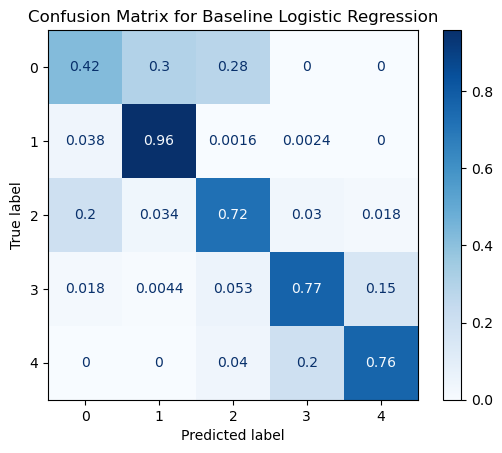

In [46]:
# plot the confusion matrix for the baseline model
cm = confusion_matrix(y_test, y_pred_baseline, labels=baseline_model.classes_, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=baseline_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Baseline Logistic Regression")
plt.show()

In [47]:
# check the balanced accuracy
balanced_accuracy_baseline_random = balanced_accuracy_score(y_test, y_pred_baseline)
print(balanced_accuracy_baseline_random)

0.7262422109003934


In [48]:
## Holdout 'Amikacin' and 'Kanamycin' because they are both aminoglycosides
holdout_drugs_two = ['Amikacin', 'Kanamycin']
holdout_codes = [code for code, drug in lookup_drugs.items() if drug in holdout_drugs_two]
print(f"Holdout drug codes: {holdout_codes}")

stress_test_two_drugs = final_ml.copy()
stress_test_two_drugs.replace([np.inf, -np.inf], np.nan, inplace=True) # replace any inf values with nan
stress_test_two_drugs = stress_test_two_drugs.fillna(-1) # fill any nan values

train_holdout2 = stress_test_two_drugs[~stress_test_two_drugs["drug"].isin(holdout_codes)].copy()
test_holdout2 = stress_test_two_drugs[stress_test_two_drugs["drug"].isin(holdout_codes)].copy()

X_train_holdout2 = train_holdout2.drop(columns=["grade_ordinal", "drug"])
y_train_holdout2 = train_holdout2["grade_ordinal"]
X_test_holdout2 = test_holdout2.drop(columns=["grade_ordinal", "drug"])
y_test_holdout2 = test_holdout2["grade_ordinal"]

print(f"Training set shape: {X_train_holdout2.shape}")
print(f"Holdout set shape: {X_test_holdout2.shape}")

Holdout drug codes: [0, 8]
Training set shape: (43722, 2170)
Holdout set shape: (4430, 2170)


In [49]:
# first remove any columns with inf values, then fill any remaining nan values with the median of each column
# scale the data
scaler = StandardScaler()
XS_train_holdout2 = scaler.fit_transform(X_train_holdout2)
XS_test_holdout2 = scaler.transform(X_test_holdout2)

# convert back to dataframe
XS_train_holdout2 = pd.DataFrame(XS_train_holdout2, columns=X_train_holdout2.columns)
XS_test_holdout2 = pd.DataFrame(XS_test_holdout2, columns=X_train_holdout2.columns)

# Run a logistic regression model as a baseline
baseline_model_holdout2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_model_holdout2.fit(XS_train_holdout2, y_train_holdout2)
y_pred_baseline_holdout2 = baseline_model_holdout2.predict(XS_test_holdout2)
print("Classification Report for Baseline Logistic Regression Removing 2 drugs:")
print(classification_report(y_test_holdout2, y_pred_baseline_holdout2))

Classification Report for Baseline Logistic Regression Removing 2 drugs:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        84
           1       0.86      0.97      0.91       700
           2       0.97      0.95      0.96      3634
           3       0.00      0.00      0.00         4
           4       0.08      0.12      0.10         8

    accuracy                           0.94      4430
   macro avg       0.38      0.41      0.39      4430
weighted avg       0.94      0.94      0.94      4430



0.40911699032942844


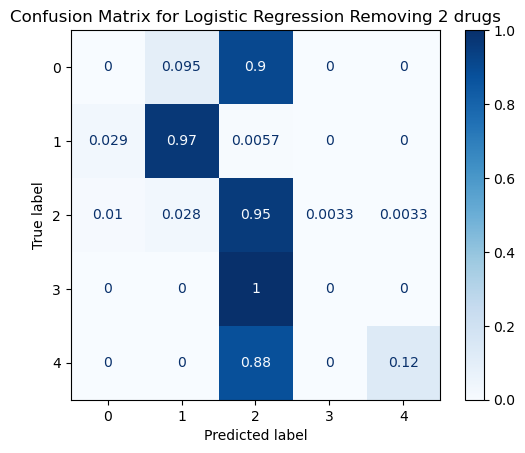

In [50]:
# check the balanced accuracy
balanced_accuracy_holdout2 = balanced_accuracy_score(y_test_holdout2, y_pred_baseline_holdout2)
print(balanced_accuracy_holdout2)

# plot the confusion matrix for the baseline model
cm_holdout = confusion_matrix(y_test_holdout2, y_pred_baseline_holdout2, labels=baseline_model_holdout2.classes_, normalize='true')
disp_holdout = ConfusionMatrixDisplay(confusion_matrix=cm_holdout, display_labels=baseline_model_holdout2.classes_)
disp_holdout.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression Removing 2 drugs")
plt.show()

### Next we will look at how reducing dimensionality might improve our accuracy scores

In [51]:
## First we know that the morgan fingerprints add the highest number of features
# let's run PCA on just the morgan fingerprints 

# copy the dataset first
X_train_fp = X_train_holdout2
y_train_fp = y_train_holdout2
X_test_fp = X_test_holdout2
y_test_fp = y_test_holdout2

# now let's remove the fingerprint columns
fp_columns = [c for c in X_train_holdout2 if c.startswith('fp_')]

# let's separate the fingerprints so we can run PCA 
X_train_fp_only = X_train_fp[fp_columns]
X_test_fp_only = X_test_fp[fp_columns]
# remaining columns like mutation data
X_train_remaining = X_train_fp.drop(columns=fp_columns)
X_test_remaining = X_test_fp.drop(columns=fp_columns)

print(f"FP shape: {X_train_fp_only.shape}")
print(f"Remaining data shape: {X_train_remaining.shape}")

FP shape: (43722, 2048)
Remaining data shape: (43722, 122)


In [52]:
# Run PCA only on the fingerprints 

# scale the data
scaler_fp = StandardScaler()

X_fp_train_scaled = scaler_fp.fit_transform(X_train_fp_only)
X_fp_test_scaled = scaler_fp.transform(X_test_fp_only)

pca = PCA(n_components=0.95, random_state=42)

# run PCA
X_fp_train_PCA = pca.fit_transform(X_fp_train_scaled)
X_fp_test_PCA = pca.transform(X_fp_test_scaled)

# convert to DF
X_fp_train_PCA = pd.DataFrame(X_fp_train_PCA, index=X_train_fp_only.index)
X_fp_test_PCA = pd.DataFrame(X_fp_test_PCA, index=X_test_fp_only.index)

In [53]:
# add the PCA columns back for hte full data readout
X_train_final_pca = pd.concat([X_train_remaining, X_fp_train_PCA], axis=1)
X_test_final_pca = pd.concat([X_test_remaining, X_fp_test_PCA], axis=1)

# convert column names to strings
X_train_final_pca.columns = [f"fp_pca_{i}" for i in range(X_train_final_pca.shape[1])]
X_test_final_pca.columns = [f"fp_pca_{i}" for i in range(X_test_final_pca.shape[1])]

# scale the full data again
scaler_full = StandardScaler()
X_train_final_pca_scaled = scaler_full.fit_transform(X_train_final_pca)
X_test_final_pca_scaled = scaler_full.transform(X_test_final_pca)

In [54]:
# Run a logistic regression model with CPA
baseline_model_pca = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_model_pca.fit(X_train_final_pca_scaled, y_train_fp)
y_pred_pca = baseline_model_pca.predict(X_test_final_pca_scaled)
print("Classification Report for Logistic Regression with PCA")
print(classification_report(y_test_fp, y_pred_pca))

Classification Report for Logistic Regression with PCA
              precision    recall  f1-score   support

           0       0.02      0.04      0.02        84
           1       0.86      0.97      0.91       700
           2       0.98      0.92      0.95      3634
           3       0.00      0.00      0.00         4
           4       0.24      0.50      0.32         8

    accuracy                           0.91      4430
   macro avg       0.42      0.49      0.44      4430
weighted avg       0.94      0.91      0.92      4430



0.485205912414498


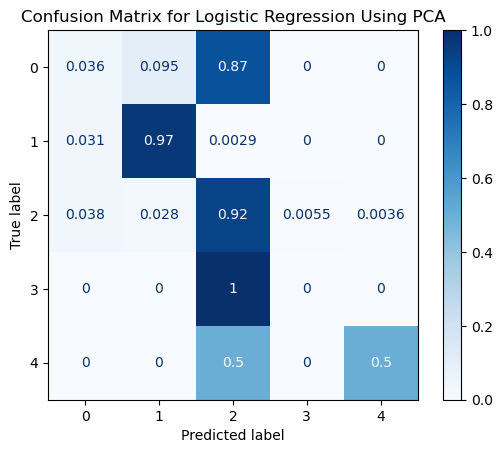

In [55]:
# check the balanced accuracy
balanced_accuracy_pca = balanced_accuracy_score(y_test_fp, y_pred_pca)
print(balanced_accuracy_pca)

# plot the confusion matrix for the baseline model
cm_pca = confusion_matrix(y_test_fp, y_pred_pca, labels=baseline_model_pca.classes_, normalize='true')
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=baseline_model_pca.classes_)
disp_pca.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression Using PCA")
plt.show()

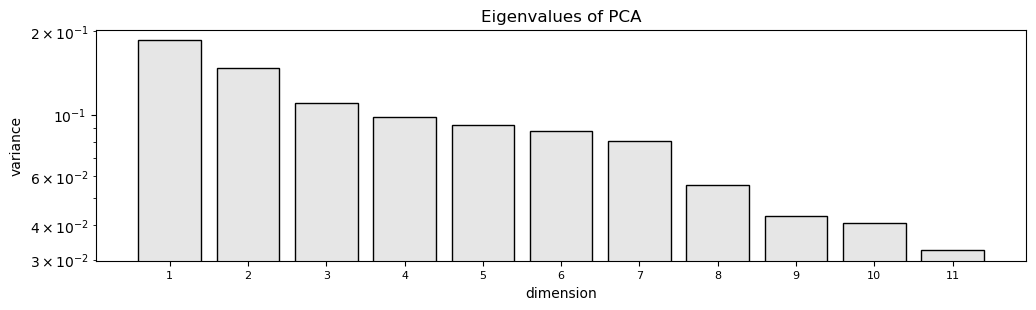

In [56]:
eigenVec = pca.components_
eigenVal = pca.explained_variance_ratio_
xplot = np.arange(1, 12)

fig = plt.figure(figsize=(12, 3))
plt.bar(xplot, eigenVal, color = (0.9, 0.9, 0.9), edgecolor = 'black')
plt.xlabel('dimension')
plt.ylabel('variance')
plt.yscale('log')
plt.xticks(xplot, size=8)
plt.title('Eigenvalues of PCA')
plt.show()

In [25]:
# finally let's just run with elastic net
# Fit a logistic regression model using elastic net, balance the data for each class

# copy the dataset first
X_train_regularization = X_train_holdout2.copy()
y_train_regularization = y_train_holdout2.copy()
X_test_regularization = X_test_holdout2.copy()
y_test_regularization = y_test_holdout2.copy()

# scale
scaler_enet = StandardScaler()

X_train_enet = scaler_enet.fit_transform(X_train_regularization)
X_test_enet = scaler_enet.transform(X_test_regularization)

# train model
enet_model = LogisticRegression(max_iter=1000, solver='saga', l1_ratio=0.1,
                                class_weight='balanced', C=0.1, random_state=42)
enet_model.fit(X_train_enet, y_train_regularization)

#predict 
y_pred_enet = enet_model.predict(X_test_enet)

print("Classification Report for Logistic Regression with Elastic Net")
print(classification_report(y_test_regularization, y_pred_enet))

Classification Report for Logistic Regression with Elastic Net
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        83
         2.0       1.00      0.98      0.99      3585
         3.0       0.00      0.00      0.00         4
         4.0       0.83      0.71      0.77         7

    accuracy                           0.98      3679
   macro avg       0.71      0.67      0.69      3679
weighted avg       1.00      0.98      0.99      3679



/Users/Bella/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.674178123132098


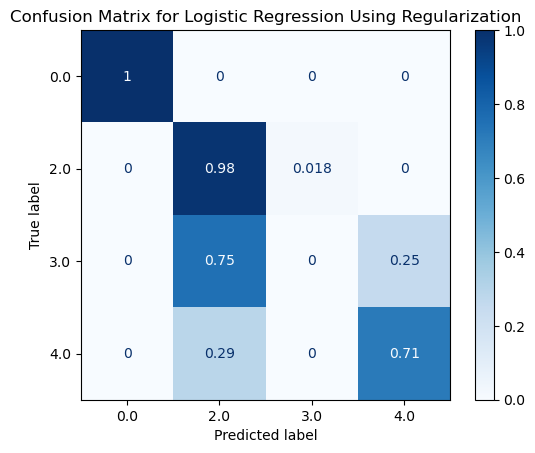

In [27]:
# check the balanced accuracy
balanced_accuracy_regularization = balanced_accuracy_score(y_test_regularization, y_pred_enet)
print(balanced_accuracy_regularization)

# plot the confusion matrix for the baseline model
cm_enet = confusion_matrix(y_test_regularization, y_pred_enet, labels=enet_model.classes_, normalize='true')
disp_enet = ConfusionMatrixDisplay(confusion_matrix=cm_enet, display_labels=enet_model.classes_)
disp_enet.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression Using Regularization")
plt.show()

              precision    recall  f1-score   support

           0       0.12      0.02      0.04        84
           1       0.82      0.99      0.90       700
           2       0.98      0.84      0.90      3634
           3       0.00      0.00      0.00         4
           4       0.02      0.50      0.04         8

    accuracy                           0.84      4430
   macro avg       0.39      0.47      0.37      4430
weighted avg       0.93      0.84      0.88      4430

Balanced Accuracy: 0.47
Epochs run: 18
Best validation score: 0.9659272810427624


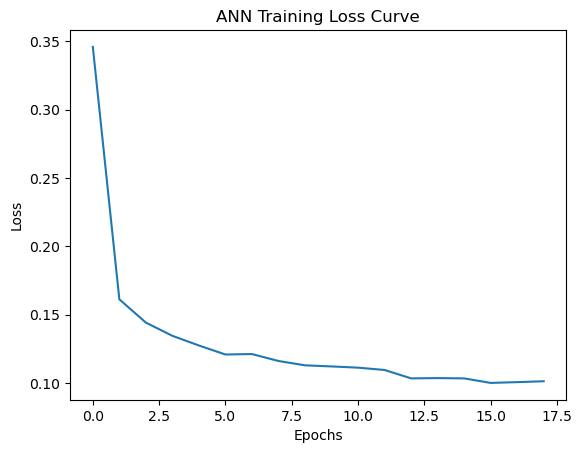

In [57]:
# test using a ANN
# set up ANN
X_train_ANN = X_train_holdout2.copy()
y_train_ANN = y_train_holdout2.copy()
X_test_ANN = X_test_holdout2.copy()
y_test_ANN = y_test_holdout2.copy()

# scale
scaler_ann = StandardScaler()
XS_train_ann = scaler_ann.fit_transform(X_train_ANN)
XS_test_ann = scaler_ann.transform(X_test_ANN)

ann_model = MLPClassifier(hidden_layer_sizes=(64,32),
                                  activation="relu",
                                  alpha=0.001,
                                  max_iter=500,
                                  random_state=42,
                                  early_stopping=True,
                                  validation_fraction=0.1)

ann_model.fit(XS_train_ann, y_train_ANN)
y_pred_ann = ann_model.predict(XS_test_ann)
print(classification_report(y_test_ANN, y_pred_ann))

# Display the accuracy
accuracy_ann = balanced_accuracy_score(y_test_ANN, y_pred_ann)
print(f'Balanced Accuracy: {accuracy_ann:.2f}')

print(f"Epochs run:", ann_model.n_iter_)
print(f"Best validation score: {ann_model.best_validation_score_}")

plt.plot(ann_model.loss_curve_)
plt.title("ANN Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


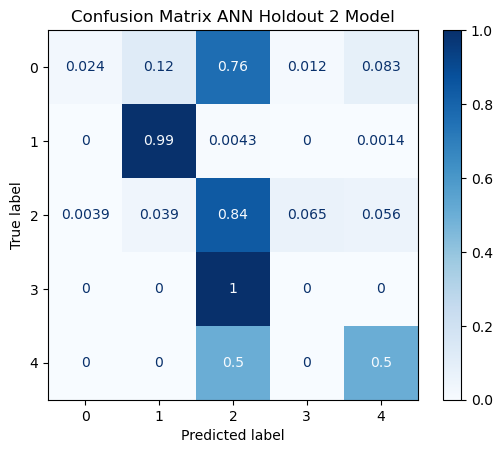

In [60]:
# Plot the confusion matrix
labels = [0, 1, 2, 3, 4]
cm_ann = confusion_matrix(y_test_ANN, y_pred_ann, normalize = 'true', labels=labels)
disp_ANN = ConfusionMatrixDisplay(confusion_matrix = cm_ann)
disp_ANN.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix ANN Holdout 2 Model")
plt.show()

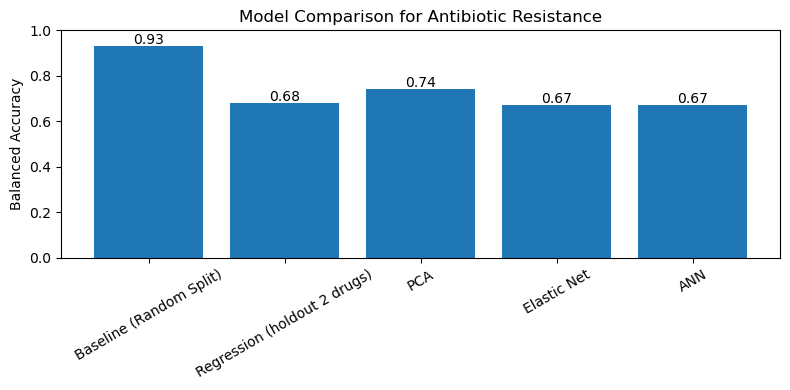

In [36]:
## now let's plot the accuracies for all the models

models = [
    "Baseline (Random Split)",
    "Regression (holdout 2 drugs)",
    "PCA",
    "Elastic Net",
    "ANN"
]

balanced_accuracies = [
    0.93,
    0.68,
    0.74,
    0.67,
    0.67
]

plt.figure(figsize=(8,4))

bars = plt.bar(models, balanced_accuracies)

plt.ylabel("Balanced Accuracy")
plt.title("Model Comparison for Antibiotic Resistance")
plt.ylim(0,1)
plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01,
             f"{height:.2f}", ha="center")
    
plt.tight_layout()
plt.show()